# **Retail Profitability Analysis**

#### Library Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

ModuleNotFoundError: No module named 'pandas'

#### Load Dataset

In [ ]:
df = pd.read_csv("../dataset/retail_cleaned_data.csv")

#### Dataset Preview (head, info, describe)

In [ ]:
df.head()

,order_id,order_date,ship_date,shipping_days,ship_mode,customer_id,customer_name,segment,country/region,city,...,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,profir_margins
0,US-2023-135405,09-01-2023,13-01-2023,4,Standard Class,MS-17830,Melanie Seite,Consumer,United States,Laredo,...,Central,OFF-AR-10004078,Office Supplies,Art,Newell 312,9.34,2,0.2,1.17,0.13
1,US-2023-135405,09-01-2023,13-01-2023,4,Standard Class,MS-17830,Melanie Seite,Consumer,United States,Laredo,...,Central,TEC-AC-10001266,Technology,Accessories,Memorex Micro Travel Drive 8 GB,31.20,3,0.2,9.75,0.31
2,US-2023-149020,10-01-2023,15-01-2023,5,Standard Class,AJ-10780,Anthony Jacobs,Corporate,United States,Springfield,...,South,FUR-FU-10000965,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Ridgewood Wall ...",51.94,1,0.0,21.30,0.41
3,US-2023-149020,10-01-2023,15-01-2023,5,Standard Class,AJ-10780,Anthony Jacobs,Corporate,United States,Springfield,...,South,OFF-LA-10004272,Office Supplies,Labels,Avery 482,2.89,1,0.0,1.36,0.47
4,US-2023-130092,11-01-2023,14-01-2023,3,First Class,SV-20365,Seth Vernon,Consumer,United States,Dover,...,East,FUR-FU-10000010,Furniture,Furnishings,DAX Value U-Channel Document Frames Easel Back,9.94,2,0.0,3.08,0.31


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        10194 non-null  str    
 1   order_date      10194 non-null  str    
 2   ship_date       10194 non-null  str    
 3   shipping_days   10194 non-null  int64  
 4   ship_mode       10194 non-null  str    
 5   customer_id     10194 non-null  str    
 6   customer_name   10194 non-null  str    
 7   segment         10194 non-null  str    
 8   country/region  10194 non-null  str    
 9   city            10194 non-null  str    
 10  state_name      10194 non-null  str    
 11  postal_code     10194 non-null  str    
 12  region          10194 non-null  str    
 13  product_id      10194 non-null  str    
 14  category        10194 non-null  str    
 15  sub_category    10194 non-null  str    
 16  product_name    10194 non-null  str    
 17  sales           10194 non-null  float64
 1

In [ ]:
df.describe()

,shipping_days,sales,quantity,discount,profit,profir_margins
count,10194.000000,10194.00000,10194.000000,10194.000000,10194.00000,10194.000000
mean,4.146655,228.22587,3.791838,0.155385,28.67348,0.122458
std,5.206647,619.90687,2.228317,0.206249,232.46521,0.465057
min,0.000000,0.44000,1.000000,0.000000,-6599.98000,-2.750000
25%,3.000000,17.22000,2.000000,0.000000,1.76000,0.080000
50%,4.000000,53.91000,3.000000,0.200000,8.69000,0.270000
75%,5.000000,209.50000,5.000000,0.200000,29.29750,0.360000
max,214.000000,22638.48000,14.000000,0.800000,8399.98000,0.500000


#### Missing Values Check

In [ ]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
shipping_days     0
ship_mode         0
customer_id       0
customer_name     0
segment           0
country/region    0
city              0
state_name        0
postal_code       0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
profir_margins    0
dtype: int64

#### Date Column Conversion

In [ ]:

df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'])

## EXPLORATORY DATA ANALYSIS (EDA)

#### Total Sales & Profit

In [ ]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 2326534.5199999996
Total Profit: 292297.46


###### *The business generated $2.33M in revenue with $292K net profit, reflecting a 12.6% overall margin. However, loss-making products and excessive discounting are suppressing what should be a stronger profitability position*

#### Sales by Category (with Bar Chart)

In [ ]:
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)

print(category_sales)

category
Technology         839893.35
Furniture          754747.94
Office Supplies    731893.23
Name: sales, dtype: float64


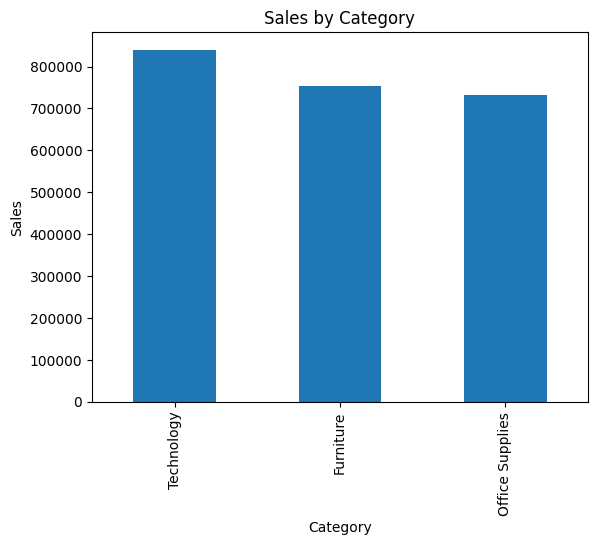

In [ ]:
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.savefig("../images/Sales by Category.png")
plt.show()

###### *Technology, Furniture, and Office Supplies each contribute roughly equal revenue (~$730K–$840K), creating a misleading picture of balanced performance. Beneath the surface, profitability varies dramatically across these three categories.*

#### Profit by Category

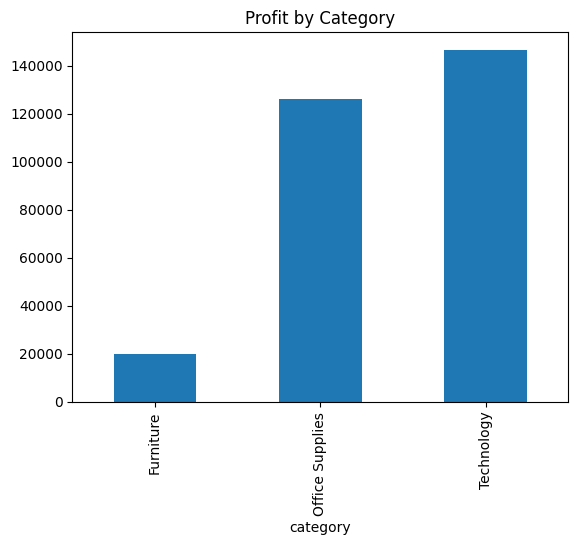

In [ ]:
category_profit = df.groupby('category')['profit'].sum()

category_profit.plot(kind='bar')

plt.savefig("../images/Profit by Category.png")
plt.title("Profit by Category")
plt.show()

###### *Technology and Office Supplies deliver ~17% net margins, while Furniture earns a critically thin 2.4% margin despite generating $755K in revenue. Furniture is the business's largest profitability liability.*

#### Monthly Sales Trend

In [ ]:
# Create month column:
df['month'] = df['order_date'].dt.to_period('M')

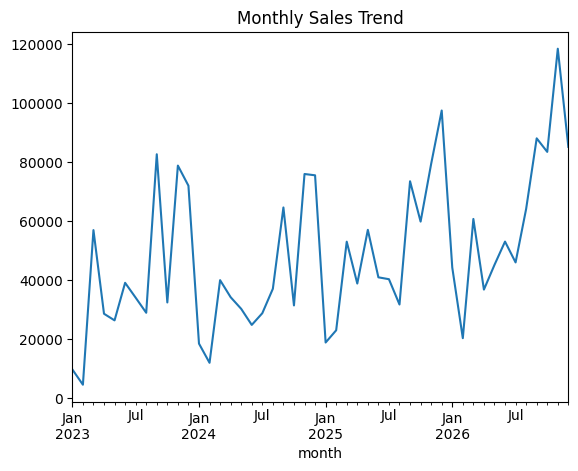

In [ ]:
# Monthly sales:
monthly_sales = df.groupby('month')['sales'].sum()

monthly_sales.plot()

plt.savefig("../images/Monthly Sales Trend.png")
plt.title("Monthly Sales Trend")
plt.show()

###### *Sales follow a clear seasonal pattern with Q4 peaks and Q1 troughs, consistent with corporate budget-driven B2B purchasing cycles. Revenue volatility between peak and off-peak months creates cash flow and inventory planning challenges.*

#### Discount vs Profit Scatter Plot

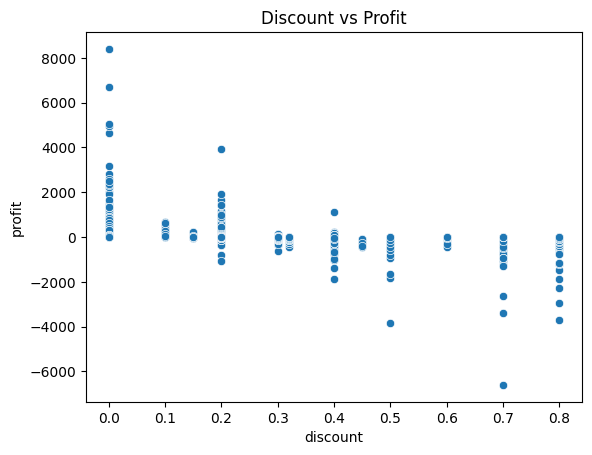

In [ ]:
sns.scatterplot(data=df, x='discount', y='profit')

plt.savefig("../images/Discount vs Profit.png")
plt.title("Discount vs Profit")
plt.show()

###### *Discounts above 30% consistently push transactions into negative profit territory, confirming that aggressive discounting is the primary driver of margin leakage across the business. Many transactions are being completed at a net loss purely due to discount depth.*

#### Correlation Heatmap

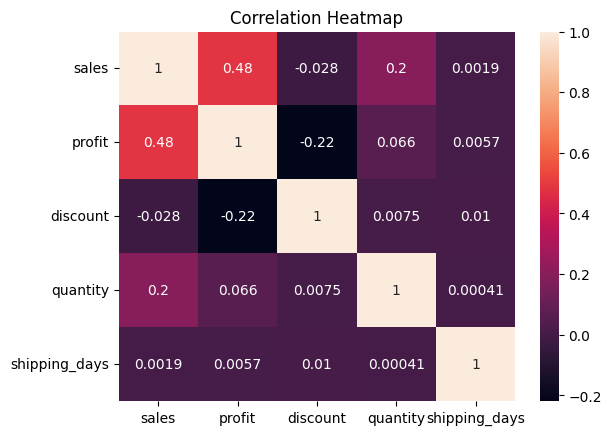

In [ ]:
correlation = df[['sales','profit','discount','quantity','shipping_days']].corr()

sns.heatmap(correlation, annot=True)

plt.savefig("../images/Correlation Heatmap.png")
plt.title("Correlation Heatmap")
plt.show()

###### *Discount shows the strongest negative correlation with profit, making it the single most controllable variable impacting business profitability. Sales volume and quantity have only a weak positive relationship with profit, meaning selling more does not automatically mean earning more.*

#### Top 10 Products by Revenue

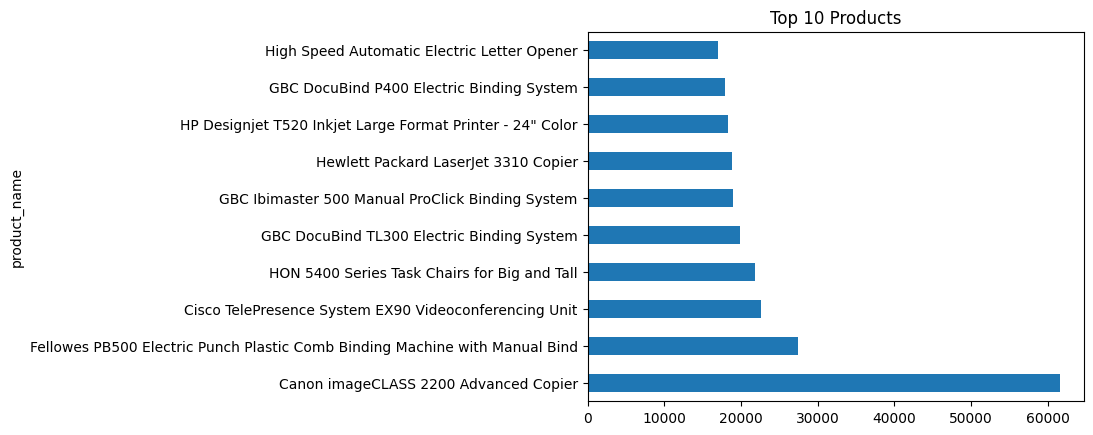

In [ ]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')

plt.savefig("../images/Top 10 Products.png")
plt.title("Top 10 Products")
plt.show()

###### *The top 10 products — all high-ticket Technology and equipment items — drive a disproportionate share of total revenue, with the Canon imageCLASS Copier alone contributing $61.6K. This concentration creates meaningful dependency risk if demand for any anchor product softens.*

#### Loss-Making Products

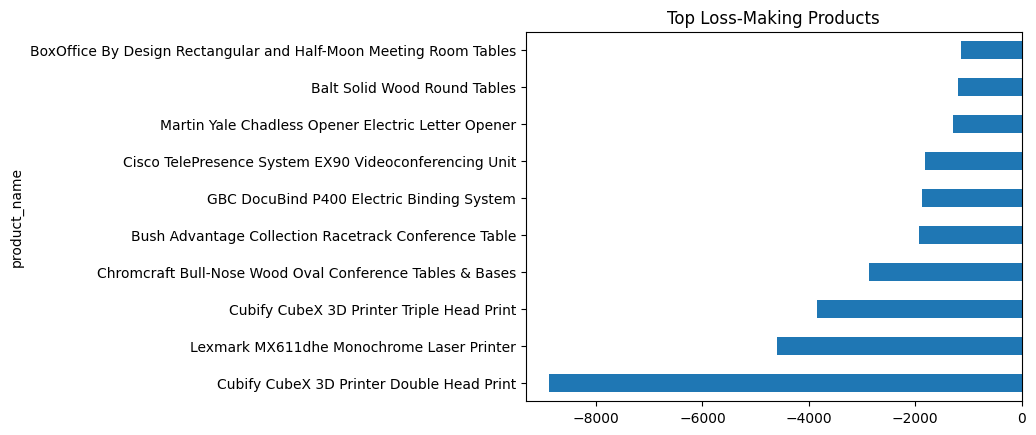

In [ ]:
loss_products = df.groupby('product_name')['profit'].sum().sort_values().head(10)

loss_products.plot(kind='barh')

plt.savefig("../images/Top Loss-Making Products.png")
plt.title("Top Loss-Making Products")
plt.show()

###### *The top 10 loss-making products collectively destroy significant profit, with the Cubify 3D Printer lines alone accounting for -$12.7K — products that lose money on every single sale. These are not anomalies; they are recurring, structural profit drains.*

#### Region Analysis

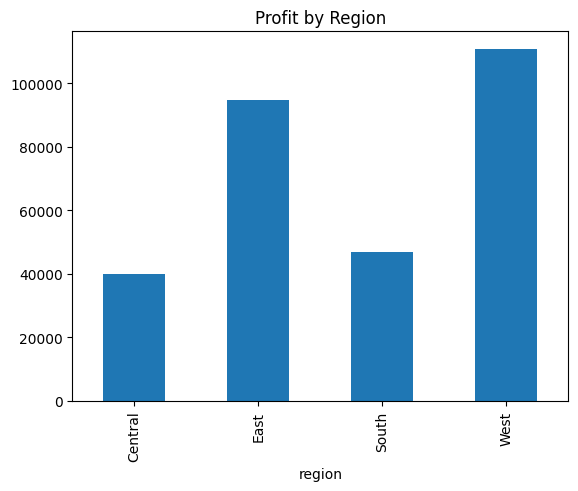

In [ ]:
region_profit = df.groupby('region')['profit'].sum()

region_profit.plot(kind='bar')

plt.savefig("../images/Profit by Region.png")
plt.title("Profit by Region")
plt.show()

###### *The West leads with a ~15% profit margin while the Central region generates $503K in revenue but only a 7.9% margin — nearly half the West's profitability efficiency. Central is consuming resources without delivering proportional returns.*

#### Shipping Mode Analysis (Pie Chart)

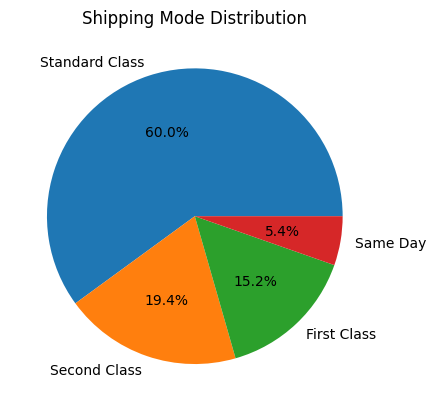

In [ ]:
shipping = df['ship_mode'].value_counts()

shipping.plot(kind='pie', autopct='%1.1f%%')

plt.savefig("../images/Shipping Mode Distribution.png")
plt.title("Shipping Mode Distribution")
plt.show()

###### *Standard Class handles 60% of all orders while Same Day shipping is used for only 5.4%, making it an underutilized premium service with disproportionate operational overhead. Most customers are clearly prioritizing cost over delivery speed.*

#### Profit Margin Distribution (Histogram)

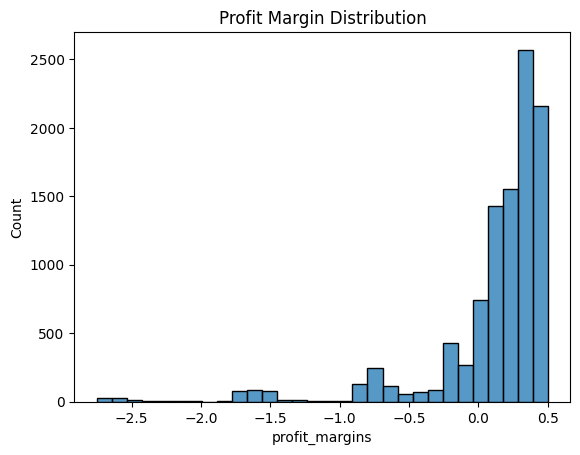

In [ ]:
if 'profit_margins' not in df.columns and 'profir_margins' in df.columns:
    df['profit_margins'] = df['profir_margins']

sns.histplot(df['profit_margins'], bins=30)

plt.savefig("../images/Profit Margin Distribution.png")
plt.title("Profit Margin Distribution")
plt.show()

# ==================================
# RFM CUSTOMER SEGMENTATION
# ==================================

In [5]:
import sys
!{sys.executable} -m pip install pandas numpy

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.9 MB 14.4 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.9 MB 13.9 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 13.2 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   --------- ------------------------------ 2.9/12.5 MB 14.6 MB/s eta 0:00:01
   ------------------ --------------------- 5.8/12.5 MB 14.0 MB/s eta 0:00:01
   -------------------------- ------------- 8.4/12.5 MB 13.9 MB/s eta 0:00:01
   ------------------------------------ --- 11.3/12.5 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 12.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\karan\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])


NameError: name 'df' is not defined

###### *The margin distribution shows a healthy core business being dragged down by a tail of deeply negative-margin transactions, some losing over 100% of their sale value. This pattern confirms that a small subset of discounted or mispriced orders is materially suppressing overall company profitability.*

***Strategic Business Recommendations***

*Control Discounting Aggressively: Cap standard discounts at 20% and require management approval beyond that threshold, as discounting above 30% consistently converts profitable transactions into losses.*

*Rationalize the Product Portfolio: Immediately delist chronic loss-makers like the Cubify 3D Printer line and place all 302 loss-making SKUs on a 90-day repricing or discontinuation review.*

*Fix the Furniture Category: Despite ranking second in revenue, Furniture's 2.4% margin is a structural liability; audit its pricing, supplier costs, and discount patterns before continuing to invest in this category.*

*Prioritize High-ROI Regions: Reallocate marketing and sales resources toward the West (15% margin) and East (13.7% margin) while investigating and addressing the Central region's profitability gap (7.9% margin).*

*Shift KPIs from Revenue to Profit Margin: Replace volume-based sales targets with margin-weighted performance metrics across all categories, regions, and sales teams to align business growth with sustainable profitability.*